# Task:

The task is a translation between two languages, specifically passing
from the **infix notation** for mathemtical expressions —where the operator appears between two operands—to **postfix** notation (also known as Reverse Polish Notation), where the operator follows the operands.

Infix notation is the most commonly used in human-readable mathematics (e.g., a + b), but it is inherently ambiguous without additional syntactic aids such as parentheses or operator precedence rules. This ambiguity arises because different parse trees can correspond to the same expression depending on how operations are grouped.

In contrast, postfix notation eliminates the need for parentheses entirely. The order of operations is explicitly encoded by the position of the operators relative to the operands, making it more suitable for stack-based evaluation and easier to parse programmatically.

**Example:**

Consider the ambiguous infix expression:
a + b * c

This expression can be parsed in at least two different ways:

Interpretation (Infix):	(a + b) * c	   
Equivalent Postfix: ab+c*

Interpretation (Infix):	a + (b * c)	          
Equivalent Postfix: abc*+


This project aims to learn such disambiguations and generate the correct postfix form from a given infix expression using a data-driven approach based on neural networks.

To simplify the task and control the complexity of expressions, we restrict our dataset to formulae with a maximum syntactic depth of 4. This means that the abstract syntax trees representing these expressions will have at most three levels, ensuring that the neural network operates on a bounded and manageable set of possible structures.

In [2]:
import random
import string
import gdown
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
if len(tf.config.list_physical_devices('GPU')) > 0:
    print("GPU is available")
else:
    print("No GPU found - running on CPU")

GPU is available


We build formulae using 6 identifiers a,b,c,d,e,f and 4 binary operators +,-,*,/.
For simplicity we do not take advantage of precedence or associativity rules for infix notation, and suppose that all binary operations as always fully parenthesizes: (e1 op e2).

In [4]:
# -------------------- Constants --------------------
OPERATORS = ['+', '-', '*', '/']
IDENTIFIERS = list('abcdef')
SPECIAL_TOKENS = ['PAD', 'SOS', 'EOS']
SYMBOLS = ['(', ')', '+', '-', '*', '/']
VOCAB = SPECIAL_TOKENS + SYMBOLS + IDENTIFIERS + ['JUNK'] #may use junk in autoregressive generation

token_to_id = {tok: i for i, tok in enumerate(VOCAB)}
id_to_token = {i: tok for tok, i in token_to_id.items()}
VOCAB_SIZE = len(VOCAB)
PAD_ID = token_to_id['PAD']
EOS_ID = token_to_id['EOS']
SOS_ID = token_to_id['SOS']

MAX_DEPTH = 4
MAX_LEN = 4*2**MAX_DEPTH -2 #enough to fit expressions at given depth (+ EOS)

In [5]:
# -------------------- Expression Generation --------------------
def generate_infix_expression(max_depth):
    if max_depth == 0:
        return random.choice(IDENTIFIERS)
    elif random.random() < 0.25:
        return generate_infix_expression(max_depth - 1)
    else:
        left = generate_infix_expression(max_depth - 1)
        right = generate_infix_expression(max_depth - 1)
        op = random.choice(OPERATORS)
        return f'({left} {op} {right})'

def tokenize(expr):
    return [c for c in expr if c in token_to_id]

def infix_to_postfix(tokens):
    precedence = {'+': 1, '-': 1, '*': 2, '/': 2}
    output, stack = [], []
    for token in tokens:
        if token in IDENTIFIERS:
            output.append(token)
        elif token in OPERATORS:
            while stack and stack[-1] in OPERATORS and precedence[stack[-1]] >= precedence[token]:
                output.append(stack.pop())
            stack.append(token)
        elif token == '(':
            stack.append(token)
        elif token == ')':
            while stack and stack[-1] != '(':
                output.append(stack.pop())
            stack.pop()
    while stack:
        output.append(stack.pop())
    return output

def encode(tokens, max_len=MAX_LEN):
    ids = [token_to_id[t] for t in tokens] + [EOS_ID]
    return ids + [PAD_ID] * (max_len - len(ids))

def decode_sequence(token_ids, id_to_token, pad_token='PAD', eos_token='EOS'):
    """
    Converts a list of token IDs into a readable string by decoding tokens.
    Stops at the first EOS token if present, and ignores PAD tokens.
    """
    tokens = []
    for token_id in token_ids:
        token = id_to_token.get(token_id, '?')
        if token == eos_token:
            break
        if token != pad_token:
            tokens.append(token)
    return ' '.join(tokens)

def generate_dataset(n,max_depth=MAX_DEPTH):
    X, Y = [], []
    for _ in range(n):
        expr = generate_infix_expression(MAX_DEPTH)
        #expr = expr_gen.generate(max_depth=max_dthep)
        infix = tokenize(expr)
        postfix = infix_to_postfix(infix)
        X.append(encode(infix))
        Y.append(encode(postfix))
    return np.array(X), np.array(Y)

#you might use the shift function for teacher-forcing
def shift_right(seqs):
    shifted = np.zeros_like(seqs)
    shifted[:, 1:] = seqs[:, :-1]
    shifted[:, 0] = SOS_ID
    return shifted

Let us define a simple dataset, and inspect a few samples. You can use a larger dataset, if you want, or directly use the generator.

In [6]:
X_train, Y_train = generate_dataset(20000)
decoder_input_train = shift_right(Y_train)

# Dataset
X_val, Y_val = generate_dataset(1000)
decoder_input_val = shift_right(Y_val)

print(f"\nTraining shapes:")
print(f"  Encoder input: {X_train.shape}")
print(f"  Decoder input: {decoder_input_train.shape}")
print(f"  Decoder target: {Y_train.shape}")


Training shapes:
  Encoder input: (20000, 62)
  Decoder input: (20000, 62)
  Decoder target: (20000, 62)


In [7]:
i =  np.random.randint(15000)
print(i)
print("infix : ",decode_sequence(X_train[i],id_to_token))
print("posfix notation: ",decode_sequence(Y_train[i],id_to_token))
print("teacher forcing : ", decode_sequence(decoder_input_train[i],id_to_token))

9829
infix :  ( ( c + a ) + ( a / d ) )
posfix notation:  c a + a d / +
teacher forcing :  SOS c a + a d / +


# LSTM Solution

We define an **encoder–decoder architecture with attention** is defined, where both the encoder and the decoder are implemented using **Long Short-Term Memory** (LSTM) networks.

In addition, an attention mechanism allows the decoder to dynamically focus on the most relevant parts of the input sequence when generating each output token, which is useful for handling nested expressions.

Keras provides two different attention mechanisms suitable for this task: **dot-product attention** (also known as Luong-style attention) and **additive attention** (also known as Bahdanau-style attention). Dot-product attention computes alignment scores using the inner product between encoder and decoder states, while additive attention uses a learned feed-forward network to compute these scores, offering greater flexibility at the cost of additional parameters.

To assess the impact of the attention mechanism, two variants of the same encoder–decoder architecture are implemented, differing only in the type of **attention layer** employed, and then their performance is compared.

## Google Drive
Prior to defining the models, we specify a dictionary of model weight file IDs and a helper function to download the weights from Google Drive, enabling reuse of the trained models without repeating the training process.

In [60]:
GDRIVE_WEIGHTS = {
    "model_dot-product_attention" : "1wsmj7P81nKrafX5dDNz-_GAhAnruKLSi",
    "model_additive_attention" : "1U28lwk-SQ7_PYiBgkwGfiNPUdLReksFx"
}

In [61]:
def download_model_params(model):
  """
    This function downloads the model's weights from Google Drive
  """
  file_id = GDRIVE_WEIGHTS.get(model.name)
  url = f"https://drive.google.com/uc?id={file_id}"
  try:
    gdown.download(url, f"{model.name}.weights.h5", quiet=False)
    model.load_weights(f"{model.name}.weights.h5")
    print("\nWeights downloaded.")
  except Exception as e:
    print(f"Error downloading weights for {model.name}: {e}")
    raise Exception("Download failed.")

The following constant is used to decide whether to download the model weights from Google Drive or train the models from scratch.

In [62]:
LOAD_FROM_GD = True

## Model Definition

First, two constants are defined:
- `EMB_SIZE`, which specifies the dimensionality of the embedding layer,
- `HIDDEN_STATE_SIZE`, which defines the dimensionality of the recurrent hidden states.

Given the small vocabulary and the limited maximum length of the expressions, a compact model is sufficient. Accordingly, the embedding size is set to 32, and the hidden state dimension is set to 64. While smaller values may also be adequate, these dimensions provide a good balance between model capacity and training stability.

In [11]:
EMB_SIZE = 32
HIDDEN_STATE_SIZE = 64

Since two different attention mechanisms are considered, a function `build_model` is defined to reduce code redundancy. This function generates an encoder–decoder architecture with the specified attention layer, allowing the two model variants to share the same structure and hyperparameters while differing only in the attention mechanism.

In [51]:
def build_model(attention_type: str):
  """
    This function generates an encoder-decoder architecture with
    the specified attention layer

    Input:
      attention_type: the type of attention layer, dot-product or additive
  """

  # ------ Encoder Definition ------
  encoder_inputs = layers.Input(shape=(MAX_LEN,), name="encoder_inputs")

  # Embedding Layer
  encoder_embedding = layers.Embedding(
      VOCAB_SIZE,
      EMB_SIZE,
      name="enc_embedding_layer")(encoder_inputs)

  # Recurrent LSTM Layer
  encoder_lstm = layers.LSTM(
      HIDDEN_STATE_SIZE,
      return_state=True,
      return_sequences=True,
      name="encoder_lstm")

  encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
  encoder_states = [state_h, state_c]

  # ------ Decoder Definition ------
  decoder_inputs = layers.Input(shape=(MAX_LEN,), name="decoder_inputs")

  # Embedding Layer
  decoder_embedding = layers.Embedding(
      VOCAB_SIZE,
      EMB_SIZE,
      name="dec_embedding_layer")(decoder_inputs)

  # Recurrent LSTM Layer
  decoder_lstm = layers.LSTM(
      HIDDEN_STATE_SIZE,
      return_sequences=True,
      return_state=True,
      name="decoder_lstm")

  decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

  # ------ Attention Layer ------
  if attention_type == "dot-product":
    attention_layer = layers.Attention(name="attention_layer")
  else:
    attention_layer = layers.AdditiveAttention(name="attention_layer")

  context_vector = attention_layer([decoder_outputs, encoder_outputs]) #query tensor, value tensor
  #context_vector = layers.MultiHeadAttention(4,EMB_SIZE)(decoder_embedding, encoder_embedding) #query tensor, value tensor

  #decoder_concat = layers.Concatenate(axis=-1, name="concat_attention")([decoder_outputs, context_vector])
  decoder_concat = context_vector #this is an alternative

  decoder_dense = layers.Dense(
      VOCAB_SIZE,
      activation="softmax",
      name="decoder_dense")
  decoder_outputs_att = decoder_dense(decoder_concat)

  # ---- Model Definition ----
  model = models.Model(
      [encoder_inputs, decoder_inputs],
      decoder_outputs_att,
      name="model_"+attention_type+"_attention")

  model.compile(
      optimizer="adam",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
  model.summary()

  return model

Let us first build the model with **dot-product attention** and inspect its parameters.

In [43]:
model_1 = build_model("dot-product")

Model: "model_dot-product_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding_layer │ (None, 62, 32)    │        512 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding_layer │ (None, 62, 32)    │        512 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 62, 64),  │     24,832 │ enc_embedding_la… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 62, 64),  │     24,832 │ dec_embedding_la… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 62, 64)    │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 62, 16)    │      1,040 │ attention_layer[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,728 (202.06 KB)

 Trainable params: 51,728 (202.06 KB)

 Non-trainable params: 0 (0.00 B)

The model has little more than 50k parameters.

We now build the model with **additive attention**.

In [52]:
model_2 = build_model("additive")

Model: "model_additive_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_embedding_layer │ (None, 62, 32)    │        512 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_embedding_layer │ (None, 62, 32)    │        512 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 62, 64),  │     24,832 │ enc_embedding_la… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 62, 64),  │     24,832 │ dec_embedding_la… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 62, 64)    │         64 │ decoder_lstm[0][… │
│ (AdditiveAttention) │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 62, 16)    │      1,040 │ attention_layer[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,792 (202.31 KB)

 Trainable params: 51,792 (202.31 KB)

 Non-trainable params: 0 (0.00 B)

As expected, using additive attention slightly increases the number of parameters. However, the model still contains fewer than 52k parameters.

## Training
Both models are now ready to be trained. To prevent overfitting and reduce unnecessary training, we define an early stopping criterion using Keras `EarlyStopping` callback.

In [55]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose = 1
)

Both models are trained with a batch size of 64 for a maximum of 100 epochs, using early stopping.

We implemented the function `train_and_save_weights`, which trains a model and saves its weights to a file.

In [56]:
def train_and_save_weights(model, X_train, Y_train, decoder_input_train, X_val, Y_val, decoder_input_val):
  """
    This function trains the model and saves its weights.
  """
  history = model.fit(
      [X_train, decoder_input_train], Y_train,
      validation_data = ([X_val, decoder_input_val], Y_val),
      batch_size=64,
      epochs=100,
      callbacks = [early_stopping]
      )

  model.save_weights(f"{model.name}.weights.h5")

  return history

For each model, if `LOAD_FROM_GD` is set to `True`, the pretrained weights are downloaded from Google Drive instead of retraining the model. To start the training process, please change this constant accordingly.

We first consider the model with dot-product attention.

In [63]:
if LOAD_FROM_GD:
    try:
      download_model_params(model_1)

    except Exception as e:
      print(f"{e} Starting the training.")
      history_1 = train_and_save_weights(model_1, X_train, Y_train, decoder_input_train, X_val, Y_val, decoder_input_val)
      LOAD_FROM_GD = False
else:
      history_1 = train_and_save_weights(model_1, X_train, Y_train, decoder_input_train, X_val, Y_val, decoder_input_val)

Downloading...
From: https://drive.google.com/uc?id=1wsmj7P81nKrafX5dDNz-_GAhAnruKLSi
To: /content/model_dot-product_attention.weights.h5
100%|██████████| 661k/661k [00:00<00:00, 6.88MB/s]


Weights downloaded.


We next consider the second model with additive attention.

In [64]:
if LOAD_FROM_GD:
    try:
      download_model_params(model_2)
    except Exception as e:
      print(f"{e} Starting the training.")
      history_2 = train_and_save_weights(model_2, X_train, Y_train, decoder_input_train, X_val, Y_val, decoder_input_val)
      LOAD_FROM_GD = False
else:
  history_2 = train_and_save_weights(model_2, X_train, Y_train, decoder_input_train, X_val, Y_val, decoder_input_val)

Downloading...
From: https://drive.google.com/uc?id=1U28lwk-SQ7_PYiBgkwGfiNPUdLReksFx
To: /content/model_additive_attention.weights.h5
100%|██████████| 663k/663k [00:00<00:00, 8.21MB/s]


Weights downloaded.


We analyze the training phase by plotting the training loss and accuracy for each model.

Again, to improve clarity and reduce redundancy, the function `plot_history` is defined.

In [ ]:
def plot_history(model_history, model_name):
  """
    This function plots the model's training history
  """
  fig, axs = plt.subplots(1,2,figsize=(14,5))

  axs[0].plot(model_history.history["loss"], label="Training Loss")
  axs[0].plot(model_history.history["val_loss"], label="Validation Loss")
  axs[0].set_title(f"{model_name} - Loss")
  axs[0].set_xlabel("Epoch")
  axs[0].set_ylabel("Loss")
  axs[0].legend()
  axs[0].grid(alpha=0.4)

  axs[1].plot(model_history.history["accuracy"], label="Training Accuracy")
  axs[1].plot(model_history.history["val_accuracy"], label="Validation Accuracy")
  axs[1].set_title(f"{model_name} - Accuracy")
  axs[1].set_xlabel("Epoch")
  axs[1].set_ylabel("Accuracy")
  axs[1].legend()
  axs[1].grid(alpha=0.4)

  plt.show()

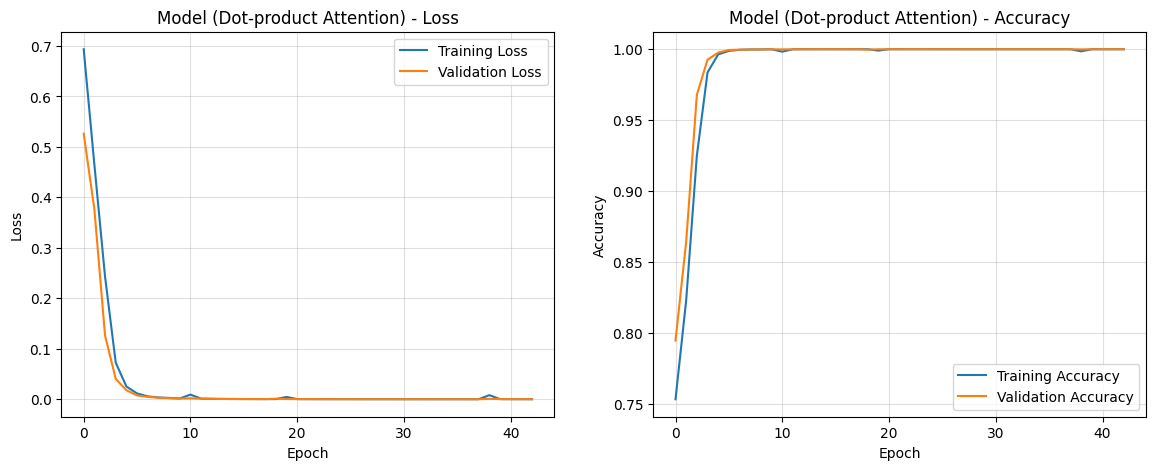

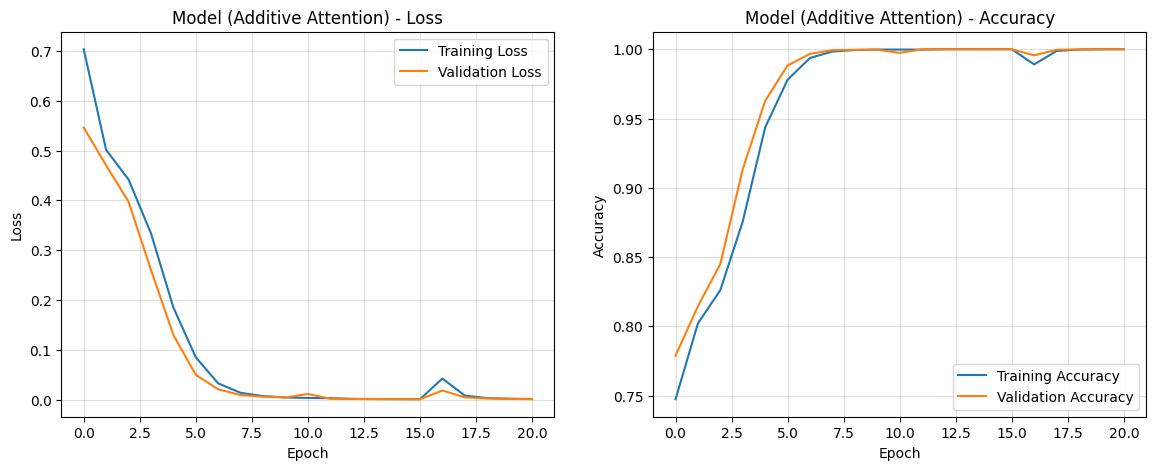

In [ ]:
if not LOAD_FROM_GD:
  plot_history(history_1, "Model (Dot-product Attention)")
  plot_history(history_2, "Model (Additive Attention)")
else:
  print("Training history is not available when loading pretrained weights.")

# Evaluation

We shall evaluate a generated item y_pred using "prefix accuracy", the lenght of
the initial prefix of y_pred matching the ground true y_true. This will be divided by the maximum length of y_true and y_pred (up to EOS), so that a perfect match has score 1.

* It's more informative than exact match (which is often 0)

* It’s tighter than edit distance: focuses on generation flow

* Captures where the model starts to make errors



In [65]:
def prefix_accuracy_single(y_true, y_pred, id_to_token, eos_id=EOS_ID, verbose=False):
    t_str = decode_sequence(y_true, id_to_token).split(' EOS')[0]
    p_str = decode_sequence(y_pred, id_to_token).split(' EOS')[0]
    t_tokens = t_str.strip().split()
    p_tokens = p_str.strip().split()
    # print(len(p_tokens))
    max_len = max(len(t_tokens), len(p_tokens))
    n = min(len(t_tokens), len(p_tokens))
    match_len = 0
    while match_len < n and t_tokens[match_len] == p_tokens[match_len]:
        match_len += 1
    score = match_len / max_len if max_len>0 else 0
    if verbose:
        print("TARGET :", ' '.join(t_tokens))
        print("PREDICT:", ' '.join(p_tokens))
        print(f"PREFIX MATCH: {match_len}/{len(t_tokens)} → {score:.2f}")

    return score

In [66]:
#example
i = np.random.randint(10000)
expected = np.copy(Y_train[i])
generated = np.copy(Y_train[i])
expr_len = np.where(generated==EOS_ID)[0][0]
j = np.random.randint(expr_len)
generated[j] = EOS_ID #making shorter
prefix_accuracy_single(expected,generated,id_to_token,verbose=True)

TARGET : f c / c a - e e * e b / - + -
PREDICT: f c / c a - e e *
PREFIX MATCH: 9/15 → 0.60


0.6

We evaluate your model on a test set of 30 expressions, repeat this evaluation 10 times, and return the mean and std for this rounds.

In [67]:
def test(model, no=30,rounds=10, verbose=False):
  rscores =[]
  for i in range(rounds):
    print("round=",i)
    X_test, Y_test = generate_dataset(no)
    scores = []
    for j in range(no):
      encoder_input=X_test[j]
      generated = autoregressive_decode(model, encoder_input)[1:] #remove SOS
      scores.append(prefix_accuracy_single(Y_test[j], generated, id_to_token, verbose=verbose))
    rscores.append(np.mean(scores))
  return np.mean(rscores),np.std(rscores)

Here we define the function for autoregressive decoding.

This definition is simple altough a bit inefficient. We can call the decoder passing just the last output token as input, provided we also pass the final internal state of the lstm. Here we recreate the state by reprocessing the full output sequence.

In [68]:
def autoregressive_decode(model, encoder_input):
  """
    This function implements autoregressive decoding for an encoder–decoder model.
  """
  encoder_input = np.array(encoder_input)[np.newaxis, :]

  # Initialize input with SOS
  sos_id = token_to_id['SOS']
  target_seq = np.array([[sos_id]])
  predicted_tokens = [sos_id]

  for _ in range(MAX_LEN):
      prediction = model.predict([encoder_input, target_seq], verbose=0)
      predicted_id = int(np.argmax(prediction[0, -1, :]))
      predicted_tokens.append(predicted_id)

      # Stop if EOS reached
      if predicted_id == EOS_ID:
          break

      # Update the input
      target_seq = np.concatenate([target_seq, [[predicted_id]]], axis=1)
  return predicted_tokens

Finally, we test our models.

In [74]:
res, std = test(model_1, no=1, rounds=1,verbose=True)
print("score=",res,"std=",std)

round= 0
TARGET : f d / f d + + f a * + f f / d f + * d f - f f - + * /
PREDICT: f d / f d + + f a * + f f / d f + * d f - f f - + * /
PREFIX MATCH: 27/27 → 1.00
score= 1.0 std= 0.0


In [ ]:
res, std = test(model_2)
print("score=",res,"std=",std)

round= 0
round= 1
round= 2
round= 3
round= 4
round= 5
round= 6
round= 7
round= 8
round= 9
score= 1.0 std= 0.0


Both models perform very well, accurately translating the expressions.

# Conclusion

In this notebook, we investigated the use of attention-based encoder–decoder architectures for translating mathematical expressions from infix to postfix notation. Two models were implemented with identical architectures, differing only in the type of attention mechanism employed: dot-product (Luong-style) attention and additive (Bahdanau-style) attention. Experimental results show that both models achieve perfect performance in most evaluation runs, with occasional minor deviations (e.g., accuracy values around 0.99). However, in most cases we reach a **mean accuracy** of 1.0 and a **standard deviation** of 0.0. This indicates that, for the considered task, both attention mechanisms are equally effective.

In summary, these results suggest that for small, well-structured symbolic translation tasks, a **compact sequence-to-sequence** model with a simple attention mechanism is adequate. More complex attention mechanisms or larger architectures would likely become beneficial for tasks involving deeper expressions and larger vocabularies.